In [1]:
# =========================================================
# STEP 4 — COMPLAINT CATEGORY CLASSIFICATION
# + URGENCY PREDICTION
# FILE: notebooks/03_complaint_classification.ipynb
# PROJECT: Smart Complaint Analytics System
# INPUT : data/processed/clean_complaints.csv
# OUTPUT: models/complaint_classifier.pkl
#         models/urgency_classifier.pkl
#         models/tfidf_vectorizer.pkl
# =========================================================

# =========================================================
# 4.1 IMPORT LIBRARIES
# =========================================================

import warnings
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.family"] = "DejaVu Sans"

In [2]:
# =========================================================
# 4.2 LOAD CLEAN DATASET
# =========================================================

DATA_PATH = Path("../data/processed/clean_complaints.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 25)


,complaint_id,created_at,channel,citizen_comment,complaint_category,department,district,village,sentiment,urgency_level,...,engagement_score,year,month,month_name,quarter,day_of_week,is_resolved,sla_met_flag,is_critical,priority_bucket
0,CMP-04708,2024-01-01 03:40:36,Call Center,Tempat pembuangan di Dadaprejo sudah penuh.,Waste Management,Dinas Lingkungan Hidup,Junrejo,Dadaprejo,Negative,Medium,...,3877,2024,1,January,1,Monday,1,0,0,Medium
1,CMP-07774,2024-01-01 03:43:25,Call Center,Aspal rusak parah di daerah Temas dan belum di...,Road Infrastructure,Dinas PUPR,Batu,Temas,Negative,Low,...,845,2024,1,January,1,Monday,1,0,0,Low
2,CMP-01189,2024-01-01 06:35:30,LAPOR!,Air PDAM di Mojorejo keruh dan tidak layak dig...,Clean Water,PDAM,Bumiaji,Mojorejo,Neutral,Medium,...,1187,2024,1,January,1,Monday,0,0,0,Medium
3,CMP-01853,2024-01-01 10:09:18,Website,Genangan air sering terjadi di Dadaprejo saat ...,Flooding,Dinas PUPR,Junrejo,Dadaprejo,Neutral,High,...,4440,2024,1,January,1,Monday,0,0,0,High
4,CMP-07824,2024-01-01 14:43:25,TikTok,Lampu jalan rusak di kawasan Gunungsari.,Street Lighting,Dinas Perhubungan,Junrejo,Gunungsari,Negative,Medium,...,1780,2024,1,January,1,Monday,1,1,0,Medium


In [3]:
# =========================================================
# 4.3 TEXT FEATURES
# =========================================================

# Gunakan kombinasi teks + metadata agar model lebih realistis
df["model_text"] = (
    df["citizen_comment"].astype(str)
    + " | "
    + df["channel"].astype(str)
    + " | "
    + df["district"].astype(str)
)

print(df["model_text"].head(3))

0    Tempat pembuangan di Dadaprejo sudah penuh. | ...
1    Aspal rusak parah di daerah Temas dan belum di...
2    Air PDAM di Mojorejo keruh dan tidak layak dig...
Name: model_text, dtype: object


In [4]:
# =========================================================
# 4.4 TF-IDF VECTORIZATION
# =========================================================

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X = vectorizer.fit_transform(df["model_text"])

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (10000, 685)


In [5]:
# =========================================================
# 4.5 COMPLAINT CATEGORY CLASSIFICATION
# =========================================================

y_category = df["complaint_category"]

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X,
    y_category,
    test_size=0.20,
    random_state=42,
    stratify=y_category
)

category_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

category_results = []

best_category_model = None
best_category_name = None
best_category_f1 = 0

for name, model in category_models.items():
    model.fit(X_train_cat, y_train_cat)
    y_pred = model.predict(X_test_cat)

    acc = accuracy_score(y_test_cat, y_pred)
    f1 = f1_score(y_test_cat, y_pred, average="weighted")

    category_results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })

    print("=" * 60)
    print(f"CATEGORY CLASSIFICATION — {name}")
    print("=" * 60)
    print(classification_report(y_test_cat, y_pred))

    if f1 > best_category_f1:
        best_category_f1 = f1
        best_category_model = model
        best_category_name = name
        best_category_y_pred = y_pred

category_results_df = pd.DataFrame(category_results).sort_values(
    "F1 Score",
    ascending=False
)

category_results_df

CATEGORY CLASSIFICATION — Logistic Regression
                         precision    recall  f1-score   support

Administrative Services       1.00      1.00      1.00       197
            Clean Water       1.00      1.00      1.00       203
               Flooding       1.00      1.00      1.00       208
        Illegal Parking       1.00      1.00      1.00       198
          Public Safety       1.00      1.00      1.00       196
            Public WiFi       1.00      1.00      1.00       194
    Road Infrastructure       1.00      1.00      1.00       208
        Street Lighting       1.00      1.00      1.00       191
       Tourism Services       1.00      1.00      1.00       205
       Waste Management       1.00      1.00      1.00       200

               accuracy                           1.00      2000
              macro avg       1.00      1.00      1.00      2000
           weighted avg       1.00      1.00      1.00      2000

CATEGORY CLASSIFICATION — Naive Bayes
   

,Model,Accuracy,F1 Score
0,Logistic Regression,1.0,1.0
1,Naive Bayes,1.0,1.0
2,Linear SVM,1.0,1.0


In [6]:
# =========================================================
# 4.6 URGENCY PREDICTION
# =========================================================

y_urgency = df["urgency_level"]

X_train_urg, X_test_urg, y_train_urg, y_test_urg = train_test_split(
    X,
    y_urgency,
    test_size=0.20,
    random_state=42,
    stratify=y_urgency
)

urgency_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

urgency_results = []

best_urgency_model = None
best_urgency_name = None
best_urgency_f1 = 0

for name, model in urgency_models.items():
    model.fit(X_train_urg, y_train_urg)
    y_pred = model.predict(X_test_urg)

    acc = accuracy_score(y_test_urg, y_pred)
    f1 = f1_score(y_test_urg, y_pred, average="weighted")

    urgency_results.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })

    print("=" * 60)
    print(f"URGENCY PREDICTION — {name}")
    print("=" * 60)
    print(classification_report(y_test_urg, y_pred))

    if f1 > best_urgency_f1:
        best_urgency_f1 = f1
        best_urgency_model = model
        best_urgency_name = name
        best_urgency_y_pred = y_pred

urgency_results_df = pd.DataFrame(urgency_results).sort_values(
    "F1 Score",
    ascending=False
)

urgency_results_df

URGENCY PREDICTION — Logistic Regression
              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00       160
        High       0.20      0.05      0.07       441
         Low       0.30      0.18      0.23       587
      Medium       0.40      0.75      0.52       812

    accuracy                           0.37      2000
   macro avg       0.22      0.25      0.21      2000
weighted avg       0.29      0.37      0.29      2000

URGENCY PREDICTION — Naive Bayes
              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00       160
        High       0.22      0.07      0.11       441
         Low       0.29      0.18      0.22       587
      Medium       0.40      0.73      0.52       812

    accuracy                           0.37      2000
   macro avg       0.23      0.25      0.21      2000
weighted avg       0.30      0.37      0.30      2000

URGENCY PREDICTION — Linear SVM
              precision 

,Model,Accuracy,F1 Score
2,Linear SVM,0.368,0.313114
1,Naive Bayes,0.367,0.299990
0,Logistic Regression,0.370,0.294359


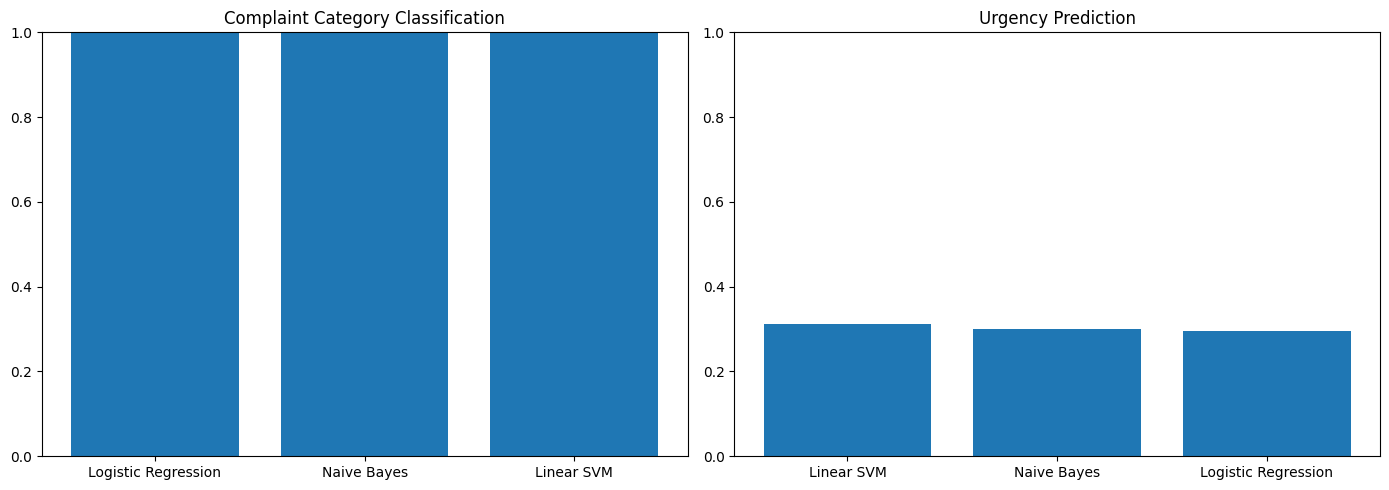

In [7]:
# =========================================================
# 4.7 MODEL PERFORMANCE VISUALIZATION
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category Classification
axes[0].bar(
    category_results_df["Model"],
    category_results_df["F1 Score"]
)
axes[0].set_title("Complaint Category Classification")
axes[0].set_ylim(0, 1)

# Urgency Prediction
axes[1].bar(
    urgency_results_df["Model"],
    urgency_results_df["F1 Score"]
)
axes[1].set_title("Urgency Prediction")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Save screenshot as:
# assets/model-performance-comparison.png

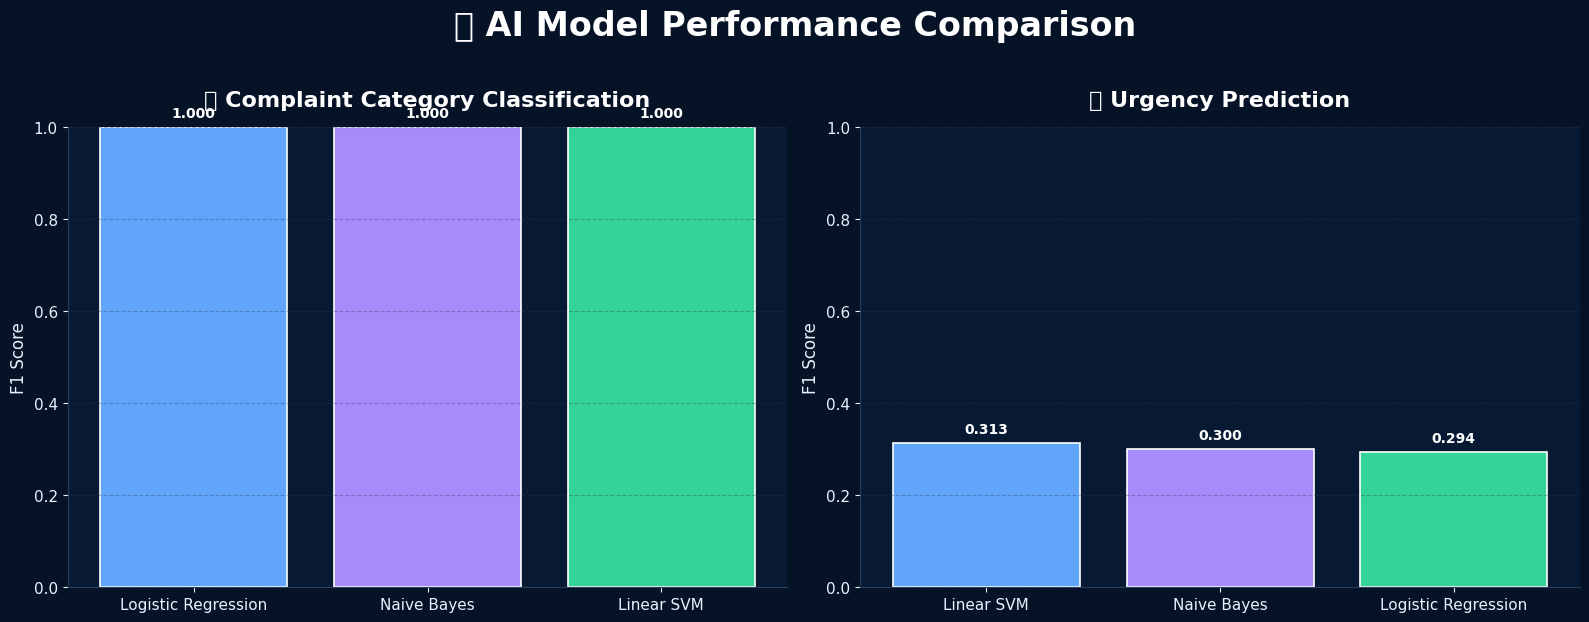

In [14]:
# =========================================================
# 4.7 MODEL PERFORMANCE VISUALIZATION (ELITE DARK THEME)
# =========================================================

import matplotlib.pyplot as plt

# Premium Dark Theme Configuration
BG_COLOR = "#061226"        # Deep navy
AX_COLOR = "#081a33"        # Card background
GRID_COLOR = "#2A3F5F"
TEXT_COLOR = "#E8F1FF"
ACCENT_COLORS = ["#60A5FA", "#A78BFA", "#34D399"]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)

# Apply common styling
for ax in axes:
    ax.set_facecolor(AX_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=11)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.spines["left"].set_color(GRID_COLOR)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color=GRID_COLOR, alpha=0.35, linestyle="--")
    ax.set_ylim(0, 1)
    ax.set_ylabel("F1 Score", color=TEXT_COLOR, fontsize=12)

# =========================================================
# LEFT PANEL — Complaint Category Classification
# =========================================================

bars1 = axes[0].bar(
    category_results_df["Model"],
    category_results_df["F1 Score"],
    color=ACCENT_COLORS,
    edgecolor="white",
    linewidth=1.2
)

axes[0].set_title(
    "🏷️ Complaint Category Classification",
    color="white",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add labels
for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

# =========================================================
# RIGHT PANEL — Urgency Prediction
# =========================================================

bars2 = axes[1].bar(
    urgency_results_df["Model"],
    urgency_results_df["F1 Score"],
    color=ACCENT_COLORS,
    edgecolor="white",
    linewidth=1.2
)

axes[1].set_title(
    "🚨 Urgency Prediction",
    color="white",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add labels
for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

# =========================================================
# GLOBAL TITLE
# =========================================================

fig.suptitle(
    "🤖 AI Model Performance Comparison",
    fontsize=24,
    fontweight="bold",
    color="white",
    y=1.03
)

fig.tight_layout()
plt.show()

# Save screenshot as:
# assets/model-performance-comparison.png

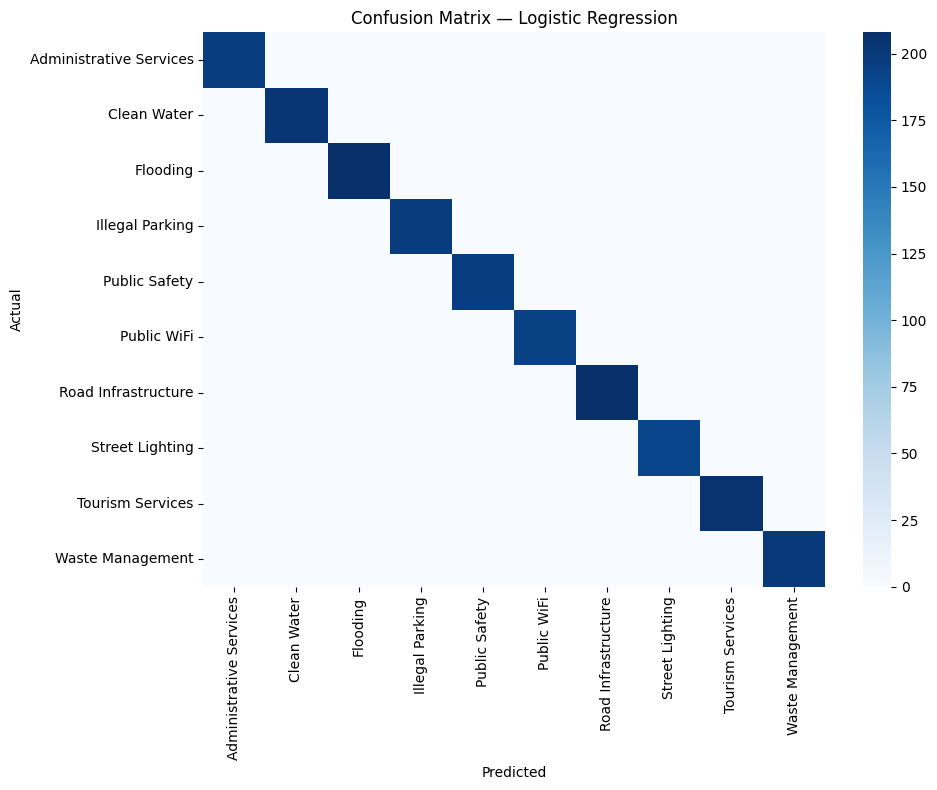

In [9]:
# =========================================================
# 4.8 CONFUSION MATRIX (BEST CATEGORY MODEL)
# =========================================================

cm = confusion_matrix(
    y_test_cat,
    best_category_y_pred,
    labels=best_category_model.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=best_category_model.classes_,
    yticklabels=best_category_model.classes_
)

plt.title(
    f"Confusion Matrix — {best_category_name}"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Save screenshot as:
# assets/category-confusion-matrix.png

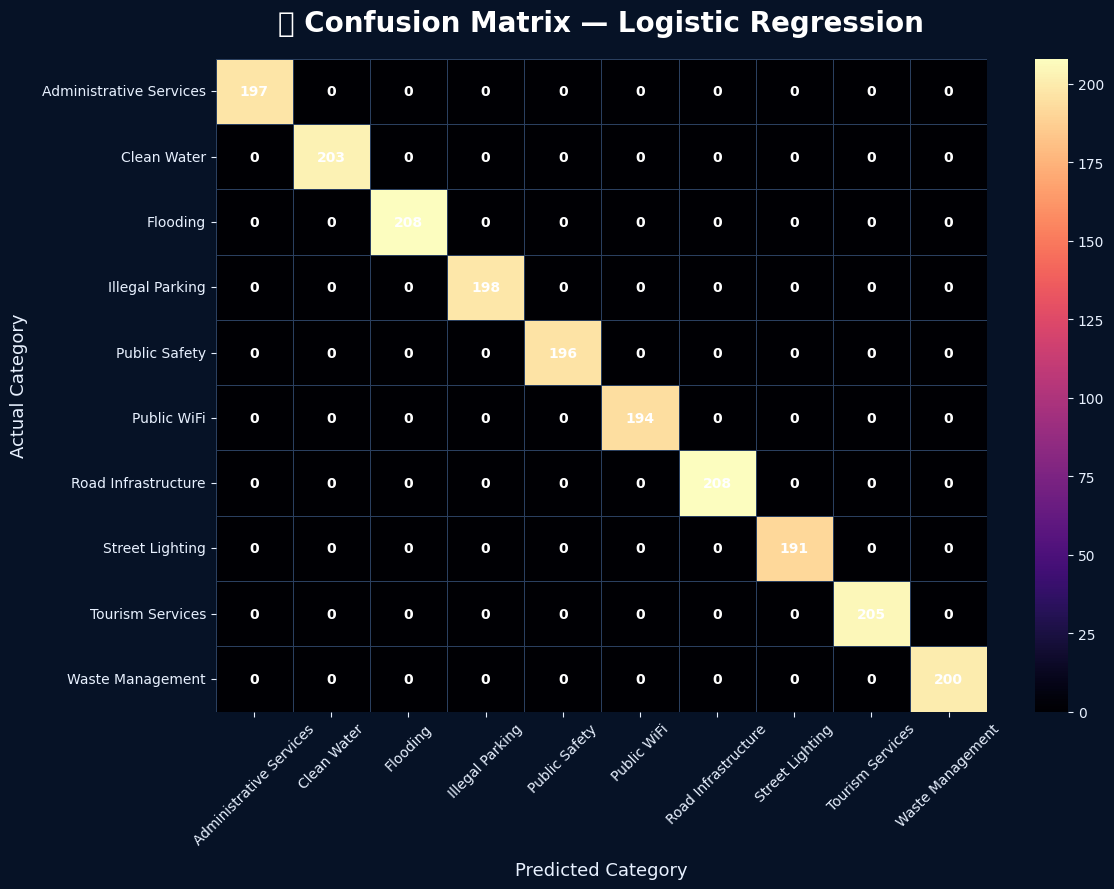

In [15]:
# =========================================================
# 4.8 CONFUSION MATRIX (ELITE DARK THEME)
# =========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_test_cat,
    best_category_y_pred,
    labels=best_category_model.classes_
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG_COLOR)
ax.set_facecolor(AX_COLOR)

# Heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma",
    linewidths=0.5,
    linecolor=GRID_COLOR,
    xticklabels=best_category_model.classes_,
    yticklabels=best_category_model.classes_,
    cbar=True,
    annot_kws={
        "color": "white",
        "fontsize": 10,
        "fontweight": "bold"
    },
    ax=ax
)

# Titles and labels
ax.set_title(
    f"🧠 Confusion Matrix — {best_category_name}",
    fontsize=20,
    fontweight="bold",
    color="white",
    pad=20
)

ax.set_xlabel(
    "Predicted Category",
    fontsize=13,
    color=TEXT_COLOR,
    labelpad=10
)

ax.set_ylabel(
    "Actual Category",
    fontsize=13,
    color=TEXT_COLOR,
    labelpad=10
)

# Tick styling
ax.tick_params(
    axis="x",
    colors=TEXT_COLOR,
    rotation=45,
    labelsize=10
)

ax.tick_params(
    axis="y",
    colors=TEXT_COLOR,
    rotation=0,
    labelsize=10
)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR)
plt.setp(cbar.ax.get_yticklabels(), color=TEXT_COLOR)

plt.tight_layout()
plt.show()

# Save screenshot as:
# assets/category-confusion-matrix.png

In [11]:
# =========================================================
# 4.9 SAVE MODELS
# =========================================================

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    best_category_model,
    MODELS_DIR / "complaint_classifier.pkl"
)

joblib.dump(
    best_urgency_model,
    MODELS_DIR / "urgency_classifier.pkl"
)

joblib.dump(
    vectorizer,
    MODELS_DIR / "tfidf_vectorizer.pkl"
)

print("Models saved successfully.")

Models saved successfully.


In [12]:
# =========================================================
# 4.10 EXECUTIVE MODEL SUMMARY
# =========================================================

print(f"""
============================================================
SMART COMPLAINT ANALYTICS SYSTEM
AI MODEL EXECUTIVE SUMMARY
============================================================

Complaint Category Model
------------------------
Best Model   : {best_category_name}
F1 Score     : {best_category_f1:.4f}

Urgency Prediction Model
------------------------
Best Model   : {best_urgency_name}
F1 Score     : {best_urgency_f1:.4f}

Strategic Insight:
The AI models can automatically classify incoming complaints
and estimate urgency levels, enabling government agencies to
prioritize critical cases and accelerate response workflows.

Saved Artifacts:
- models/complaint_classifier.pkl
- models/urgency_classifier.pkl
- models/tfidf_vectorizer.pkl
============================================================
""")


SMART COMPLAINT ANALYTICS SYSTEM
AI MODEL EXECUTIVE SUMMARY

Complaint Category Model
------------------------
Best Model   : Logistic Regression
F1 Score     : 1.0000

Urgency Prediction Model
------------------------
Best Model   : Linear SVM
F1 Score     : 0.3131

Strategic Insight:
The AI models can automatically classify incoming complaints
and estimate urgency levels, enabling government agencies to
prioritize critical cases and accelerate response workflows.

Saved Artifacts:
- models/complaint_classifier.pkl
- models/urgency_classifier.pkl
- models/tfidf_vectorizer.pkl

